# Mall Customer Segmentation — Clustering

Real dataset (see `data/mall_customers/SOURCE.md`): 200 customers, columns
`Gender, Age, Annual Income (k$), Spending Score (1-100)`. No target column —
this is unsupervised segmentation. This notebook demonstrates:

- Full EDA (PCA/clustering/outlier mixins are directly relevant here).
- Choosing `k` for KMeans via silhouette score across a range.
- Comparing `kmeans`, `gaussian_mixture`, and `birch` on the same
  preprocessing, using the library's built-in clustering evaluation
  (silhouette, Calinski-Harabasz, Davies-Bouldin, and human-readable
  per-cluster profiles).

Polars + numpy only — no pandas.

In [1]:
import polars as pl

from skyulf import EDAAnalyzer, EDAVisualizer, SkyulfPipeline

data = pl.read_csv("data/mall_customers/Mall_Customers.csv").drop("CustomerID")
data.head()

Gender,Age,Annual Income (k$),Spending Score (1-100)
str,i64,i64,i64
"""Male""",19,15,39
"""Male""",21,15,81
"""Female""",20,16,6
"""Female""",23,16,77
"""Female""",31,17,40


## 1. Full EDA

No target column here, so `EDAAnalyzer.analyze()` runs without
`target_col` — its PCA, clustering, and outlier analysis (`MultivariateMixin`)
are exactly the unsupervised tools we need before picking a segmentation
method.

In [2]:
profile = EDAAnalyzer(data).analyze()

print(f"Rows: {profile.row_count}  Missing cells: {profile.missing_cells_percentage:.2f}%")
if profile.outliers is not None:
    print(f"Outliers detected: {profile.outliers.outlier_percentage:.1f}% ({profile.outliers.method})")
if profile.clustering is not None:
    print(f"EDA's own exploratory clustering suggests structure with {len(profile.clustering.clusters)} groups")

Rows: 200  Missing cells: 0.00%
Outliers detected: 5.0% (IsolationForest)
EDA's own exploratory clustering suggests structure with 3 groups


In [3]:
EDAVisualizer(profile, data).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric         ┃ Value ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Rows           │ 200   │
│ Columns        │ 4     │
│ Missing Cells  │ 0.0%  │
│ Duplicate Rows │ 0     │
└────────────────┴───────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┓
┃ Column                 ┃  Mean ┃   Std ┃   Min ┃    Max ┃  Skew ┃  Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━┩
│ Age                    │ 38.85 │ 13.97 │ 18.00 │  70.00 │  0.48 │ -0.68 │    No     │
│ Annual Income (k$)     │ 60.56 │ 26.26 │ 15.00 │ 137.00 │  0.32 │ -0.13 │    No     │
│ Spending Score (1-100) │ 50.20 │ 25.82 │  1.00 │  99.00 │ -0.05 │ -0.84 │    No     │
└────────────────────────┴───────┴───────┴───────┴────────┴───────┴───────┴───────────┘

...

12. Clustering Structure (KMeans)

Clusters: 3 | Inertia: 295.21

┏━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ ID ┃ Size ┃ Size % ┃ Key Characteristics (Centroids)                                   ┃
┡━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  0 │   68 │  34.0% │ Age=25.84, Annual Income (k$)=42.75, Spending Score (1-100)=53.65 │
│  1 │   41 │  20.5% │ Age=32.85, Annual Income (k$)=87.34, Spending Score (1-100)=79.98 │
│  2 │   91 │  45.5% │ Age=51.27, Annual Income (k$)=61.80, Spending Score (1-100)=34.21 │
└────┴──────┴────────┴───────────────────────────────────────────────────────────────────┘

12. Smart Alerts

• Column 'Annual Income (k$)' contains significant outliers.

Displaying plots...


/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/BH7043/Skyulf/skyulf-core/skyulf/profiling/visualizer.py:721: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(x, y, c=c_values, cmap="viridis", alpha=0.8)


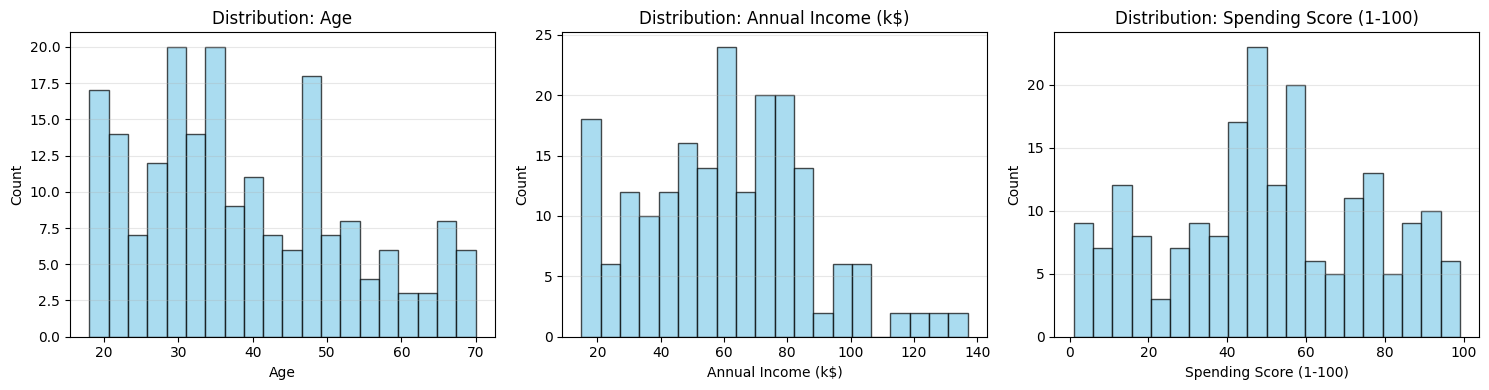

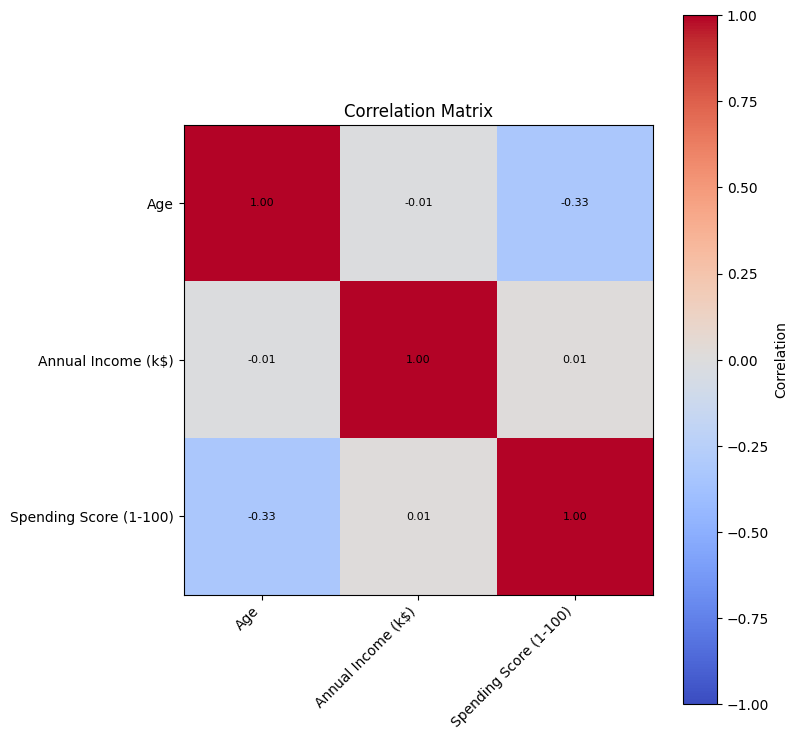

<Figure size 1000x1000 with 0 Axes>

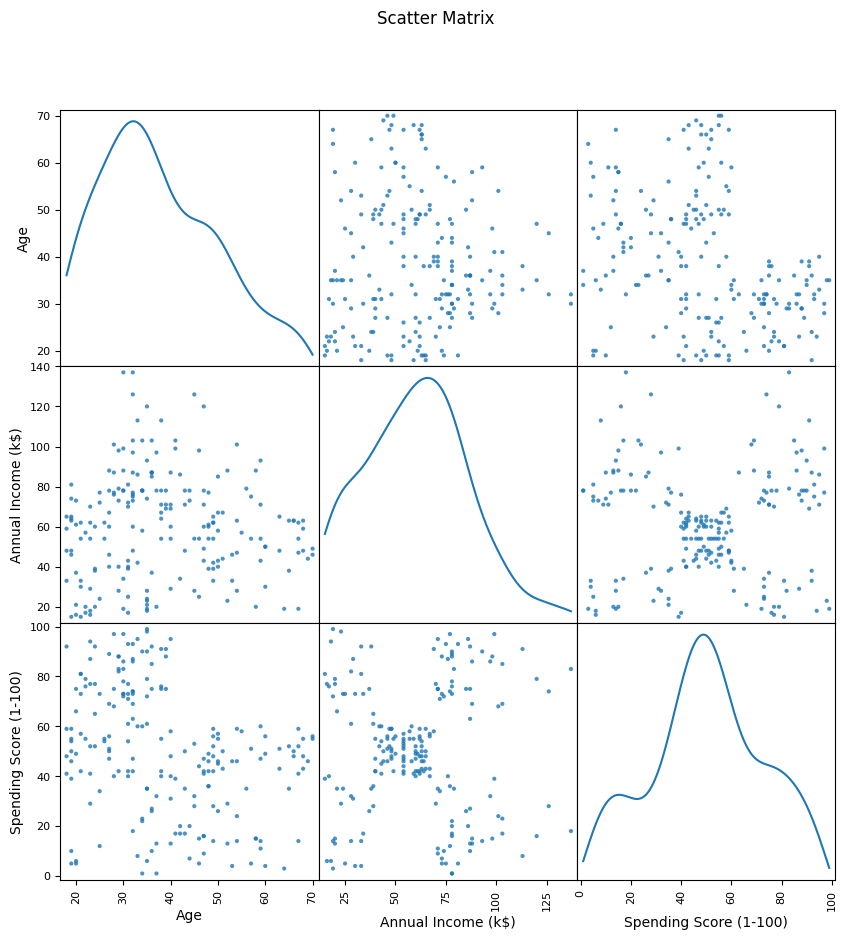

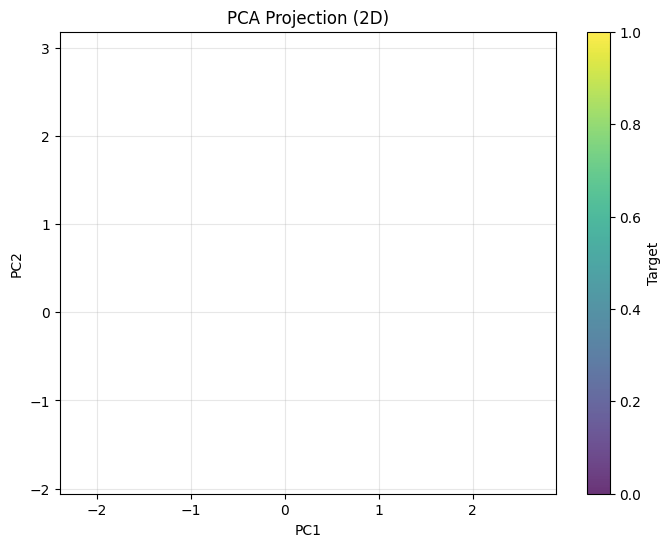

In [4]:
EDAVisualizer(profile, data).plot()

## 2. Preprocessing (shared across all clustering runs)

We one-hot encode `Gender` and standard-scale the numeric columns. There's
no target, so `TrainTestSplitter` is called with `target_column=""` (the
library's documented "no target" sentinel for clustering) — we still hold
out a test split to sanity-check that cluster structure generalizes, not to
prevent label leakage (there's no label).

In [5]:
NUMERIC = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

base_preprocessing = [
    {"name": "split", "transformer": "TrainTestSplitter", "params": {"target_column": "", "test_size": 0.2, "random_state": 42}},
    {"name": "encode_gender", "transformer": "OneHotEncoder", "params": {"columns": ["Gender"], "drop_original": True, "handle_unknown": "ignore"}},
    {"name": "scale", "transformer": "StandardScaler", "params": {"columns": NUMERIC}},
]

## 3. Choosing `k` for KMeans via silhouette score

In [6]:
results = []
for k in range(2, 9):
    config = {
        "preprocessing": base_preprocessing,
        "modeling": {"type": "kmeans", "params": {"n_clusters": k, "random_state": 42, "n_init": 10}},
    }
    pipeline = SkyulfPipeline(config)
    metrics = pipeline.fit(data, target_column="")
    sil = metrics["modeling"]["splits"]["test"].metrics["silhouette_score"]
    results.append((k, sil))
    print(f"k={k}: test silhouette = {sil:.3f}")

best_k = max(results, key=lambda r: r[1])[0]
print(f"\nBest k by test silhouette: {best_k}")

k=2: test silhouette = 0.304
k=3: test silhouette = 0.242


k=4: test silhouette = 0.258
k=5: test silhouette = 0.251
k=6: test silhouette = 0.255
k=7: test silhouette = 0.259
k=8: test silhouette = 0.286

Best k by test silhouette: 2


## 4. Compare algorithms at the chosen `k`

In [7]:
algo_configs = {
    "kmeans": {"type": "kmeans", "params": {"n_clusters": best_k, "random_state": 42, "n_init": 10}},
    "gaussian_mixture": {"type": "gaussian_mixture", "params": {"n_components": best_k, "random_state": 42}},
    "birch": {"type": "birch", "params": {"n_clusters": best_k}},
}

algo_results = {}
for name, modeling_config in algo_configs.items():
    pipeline = SkyulfPipeline({"preprocessing": base_preprocessing, "modeling": modeling_config})
    metrics = pipeline.fit(data, target_column="")
    test_report = metrics["modeling"]["splits"]["test"]
    algo_results[name] = test_report
    print(f"{name:18s} silhouette={test_report.metrics['silhouette_score']:.3f}  "
          f"calinski_harabasz={test_report.metrics['calinski_harabasz_score']:.1f}  "
          f"davies_bouldin={test_report.metrics['davies_bouldin_score']:.3f}")

kmeans             silhouette=0.304  calinski_harabasz=22.3  davies_bouldin=1.243
gaussian_mixture   silhouette=0.279  calinski_harabasz=19.6  davies_bouldin=1.282
birch              silhouette=0.100  calinski_harabasz=3.9  davies_bouldin=2.724


## 5. Human-readable cluster profiles (best algorithm)

In [8]:
best_algo = max(algo_results, key=lambda n: algo_results[n].metrics["silhouette_score"])
print(f"Best algorithm by silhouette: {best_algo}\n")

for centroid in algo_results[best_algo].clustering.centroids:
    print(f"Cluster {centroid.cluster_id} (n={centroid.size}, {centroid.percentage}%): {centroid.profile}")

Best algorithm by silhouette: kmeans

Cluster 0 (n=18, 45.0%): Low Age, High Spending Score (1-100)
Cluster 1 (n=22, 55.0%): High Age, Low Spending Score (1-100)


## Key takeaways

- Silhouette score is a principled way to pick `k` without ground truth —
  no need to eyeball an elbow plot.
- The auto-generated cluster `profile` strings (e.g. "High Spending Score,
  High Annual Income") are exactly the kind of narrative a marketing team
  would want from a segmentation exercise — the library does this for you.
- What to try next: add `Gender` interaction features, try DBSCAN-style
  density clustering for non-convex segments, or feed the PCA components
  from the EDA profile as pre-reduced features for higher-dimensional
  customer data.